## Домашняя работа 8-9

#### Импорты, seed и устройство

In [1]:
# импортирование основных библиотек

import os
import math
import time
import random
import json
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt

import pandas as pd

# -----------------------
# Воспроизводимость
# -----------------------
RANDOM_STATE = 42
def set_seed(seed: int = RANDOM_STATE) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# -----------------------
# Устройство
# -----------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print('torch:', torch.__version__)

Device: cpu
torch: 2.10.0+cpu


#### Данные и DataLoader

In [2]:
# загрузка датасетов

from torch.utils.data import DataLoader, TensorDataset, random_split

@dataclass
class DataConfig:
    dataset_name: str = "EMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10" | "DIGITS_FALLBACK"
    data_dir: str = "./data"
    batch_size: int = 128
    val_fraction: float = 0.15
    num_workers: int = 0
    fast_mode: bool = False
    max_train_samples: int = 12000   # используется только в fast_mode для больших датасетов
    max_val_samples: int = 2000
    max_test_samples: int = 3000

def _try_load_torchvision_dataset_(cfg: DataConfig):
    """Пытаемся загрузить torchvision-датасет.
    Возвращаем: (train_dataset, test_dataset, input_dim, num_classes, info_str)
    """
    import torchvision
    from torchvision import datasets, transforms

    name = cfg.dataset_name.upper().strip()

    if name == "KMNIST":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.KMNIST(root=cfg.data_dir, train=True, download=True, transform=transform)
        test_ds  = datasets.KMNIST(root=cfg.data_dir, train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 10, "torchvision.KMNIST (28x28, 10 классов)"
    if name == "EMNIST":
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])
        train_ds = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=True, download=True, transform=transform)
        test_ds  = datasets.EMNIST(root=cfg.data_dir, split="balanced", train=False, download=True, transform=transform)
        return train_ds, test_ds, 28 * 28, 47, "torchvision.EMNIST(split='balanced') (28x28, 47 классов)"
    
    raise ValueError(f"Unknown torchvision dataset_name={cfg.dataset_name!r}")

def load_data(cfg: DataConfig):
    try:
        train_ds, test_ds, input_dim, num_classes, info = _try_load_torchvision_dataset_(cfg)
    except Exception as e:
        print("torchvision недоступен или датасет не загрузился. Причина:", repr(e))
    #print(len(train_ds))
    val_size = int(len(train_ds) * cfg.val_fraction)
    train_size = len(train_ds) - val_size
    

    generator = torch.Generator().manual_seed(RANDOM_STATE)
    train_split, val_split = random_split(train_ds, [train_size, val_size], generator=generator)

    def maybe_subsample(ds, max_n: int):
        if not cfg.fast_mode:
            return ds
        if len(ds) <= max_n:
            return ds

        idx = torch.randperm(len(ds), generator=generator)[:max_n]
        return torch.utils.data.Subset(ds, idx.tolist())

    train_split = maybe_subsample(train_split, cfg.max_train_samples)
    val_split   = maybe_subsample(val_split,   cfg.max_val_samples)
    test_ds     = maybe_subsample(test_ds,     cfg.max_test_samples)

    train_loader = DataLoader(train_split, batch_size=cfg.batch_size, shuffle=True,  num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_split,   batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())
    test_loader  = DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers, pin_memory=torch.cuda.is_available())

    return train_loader, val_loader, test_loader, input_dim, num_classes, info

data_cfg = DataConfig(dataset_name="EMNIST", val_fraction=0.20, fast_mode=True)
train_loader, val_loader, test_loader, INPUT_DIM, NUM_CLASSES, DATA_INFO = load_data(data_cfg)

print("Dataset:", DATA_INFO)
print("Train batches:", len(train_loader), "| Val batches:", len(val_loader), "| Test batches:", len(test_loader))
print("INPUT_DIM:", INPUT_DIM, "| NUM_CLASSES:", NUM_CLASSES)





print("\n-=SANITY-CHECK=-")
def unpack_batch(batch):
    x, y = batch
    return x, y

batch = next(iter(train_loader))
x, y = unpack_batch(batch)

print("x:", type(x), x.shape, x.dtype)
print("y:", type(y), y.shape, y.dtype)

# Приведем x к виду (batch, input_dim) – нам нужен MLP
if x.dim() > 2:
    x_flat = x.view(x.size(0), -1)
else:
    x_flat = x

print("x_flat:", x_flat.shape)
print("Дипозоны значений:")
print(f"x: {x.min()} — {x.max()}")
print(f"y: {y.min()} — {y.max()}")


100.0%


Dataset: torchvision.EMNIST(split='balanced') (28x28, 47 классов)
Train batches: 94 | Val batches: 16 | Test batches: 24
INPUT_DIM: 784 | NUM_CLASSES: 47

-=SANITY-CHECK=-
x: <class 'torch.Tensor'> torch.Size([128, 1, 28, 28]) torch.float32
y: <class 'torch.Tensor'> torch.Size([128]) torch.int64
x_flat: torch.Size([128, 784])
Дипозоны значений:
x: -1.0 — 1.0
y: 0 — 46


#### Модель MLP и цикл обучения

In [3]:
# Модель MLP

class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        hidden_sizes: List[int] = [256, 128],
        activation: str = "relu",
        use_batchnorm: bool = False,
        dropout: float = 0.0,
    ):
        super().__init__()


        act_layer = {
            "relu": nn.ReLU,
            "tanh": nn.Tanh,
            "gelu": nn.GELU,
        }.get(activation.lower(), nn.ReLU)

        layers: List[nn.Module] = [nn.Flatten()]

        prev = input_dim
        for hs in hidden_sizes:
            layers.append(nn.Linear(prev, hs))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hs))
            layers.append(act_layer())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = hs

        layers.append(nn.Linear(prev, num_classes))  # logits
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

Вспомогательные функции

In [4]:
# функция обучения одной эпохи
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


# оценка модели
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float('nan'), float('nan')

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


# подстановка значений 
def fit(model, train_loader, val_loader, optimizer, criterion, epochs=15, early_stopping=None, verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )
        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак слишком большого LR. Останавливаем эксперимент.")
            break

    return history



# построение графиков изменения loss и acc
def plot_history(hist, title="",save=False):
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    if save:
        plt.savefig("artifacts/figures/curves_best.png")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [5]:
runs = pd.DataFrame(columns=['experiment_id','dataset','seed','model_summary',
                             'optimizer','lr','momentum','weight_decay',
                             'epochs_trained','best_val_accuracy','best_val_loss'])
print(runs)

Empty DataFrame
Columns: [experiment_id, dataset, seed, model_summary, optimizer, lr, momentum, weight_decay, epochs_trained, best_val_accuracy, best_val_loss]
Index: []


### Часть A (S08): регуляризация и переобучение

#### Эксперимент E1 (base)

Epoch 01/15 | train loss 2.5384, acc 0.336 | val loss 1.6868, acc 0.529 | 2.8s
Epoch 02/15 | train loss 1.4733, acc 0.574 | val loss 1.3597, acc 0.602 | 2.7s
Epoch 03/15 | train loss 1.2420, acc 0.639 | val loss 1.1941, acc 0.652 | 2.8s
Epoch 04/15 | train loss 1.1070, acc 0.677 | val loss 1.1040, acc 0.672 | 2.8s
Epoch 05/15 | train loss 0.9909, acc 0.707 | val loss 1.0362, acc 0.684 | 2.7s
Epoch 06/15 | train loss 0.8885, acc 0.730 | val loss 0.9599, acc 0.716 | 2.8s
Epoch 07/15 | train loss 0.8107, acc 0.749 | val loss 0.9267, acc 0.712 | 2.7s
Epoch 08/15 | train loss 0.7400, acc 0.767 | val loss 0.9154, acc 0.722 | 2.7s
Epoch 09/15 | train loss 0.6781, acc 0.786 | val loss 0.8477, acc 0.746 | 2.8s
Epoch 10/15 | train loss 0.6338, acc 0.798 | val loss 0.8288, acc 0.742 | 2.7s
Epoch 11/15 | train loss 0.5989, acc 0.805 | val loss 0.8233, acc 0.745 | 2.8s
Epoch 12/15 | train loss 0.5474, acc 0.825 | val loss 0.7829, acc 0.758 | 2.8s
Epoch 13/15 | train loss 0.5092, acc 0.832 | val los

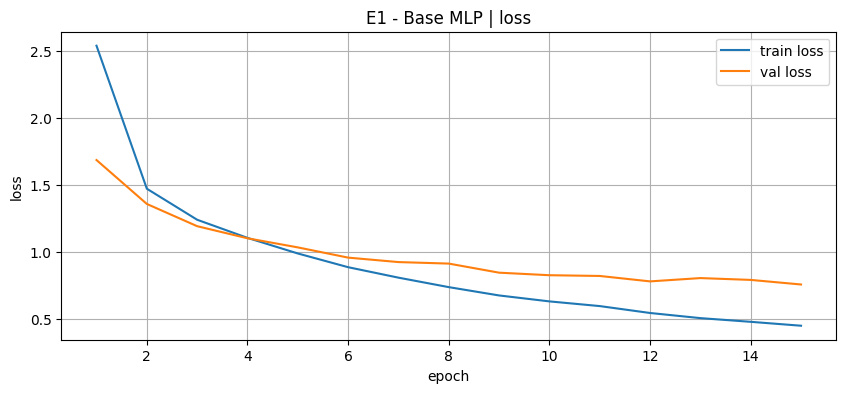

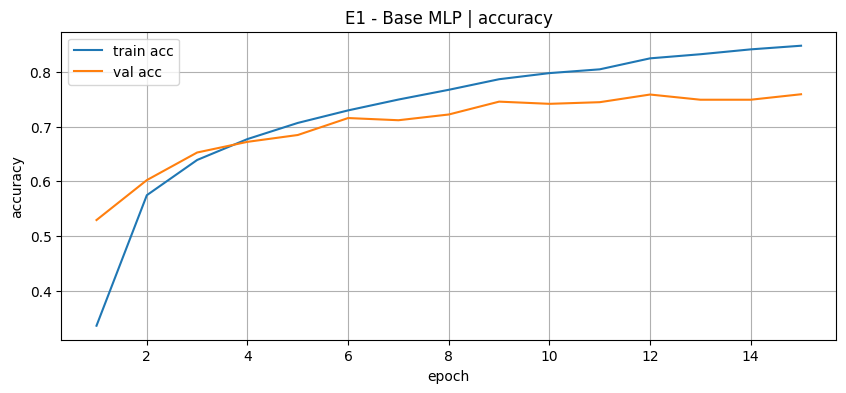

best accuracy: 0.759


C:\Users\ivanv\AppData\Local\Temp\ipykernel_13620\3329766181.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs = pd.concat([runs, pd.DataFrame([E1_data])], ignore_index=True)


In [6]:
set_seed()
model_E1 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_E1.parameters(), lr=1e-3, weight_decay=0)
history_E1 = fit(
    model_E1, train_loader, val_loader,
    optimizer, criterion,
    epochs=15,
    early_stopping=None
)
plot_history(history_E1, title="E1 - Base MLP")
E1_data = {'experiment_id': 'E1',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'base; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': 15,
            'best_val_accuracy': max(history_E1['val_acc']),
            'best_val_loss': min(history_E1['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E1_data])], ignore_index=True)
print(f"best accuracy: {max(history_E1['val_acc'])}")


#### Эксперимент E2 (Dropout)

Epoch 01/15 | train loss 2.9901, acc 0.204 | val loss 1.8712, acc 0.506 | 2.9s
Epoch 02/15 | train loss 1.9013, acc 0.455 | val loss 1.4059, acc 0.599 | 2.8s
Epoch 03/15 | train loss 1.5917, acc 0.537 | val loss 1.2255, acc 0.641 | 2.8s
Epoch 04/15 | train loss 1.4279, acc 0.576 | val loss 1.1174, acc 0.658 | 2.8s
Epoch 05/15 | train loss 1.3073, acc 0.610 | val loss 1.0550, acc 0.675 | 2.8s
Epoch 06/15 | train loss 1.2253, acc 0.628 | val loss 0.9885, acc 0.704 | 2.9s
Epoch 07/15 | train loss 1.1570, acc 0.645 | val loss 0.9323, acc 0.713 | 2.8s
Epoch 08/15 | train loss 1.1024, acc 0.662 | val loss 0.8999, acc 0.721 | 2.9s
Epoch 09/15 | train loss 1.0542, acc 0.673 | val loss 0.8743, acc 0.726 | 2.9s
Epoch 10/15 | train loss 1.0145, acc 0.681 | val loss 0.8424, acc 0.739 | 2.9s
Epoch 11/15 | train loss 0.9685, acc 0.697 | val loss 0.8045, acc 0.739 | 3.0s
Epoch 12/15 | train loss 0.9533, acc 0.702 | val loss 0.7948, acc 0.753 | 3.0s
Epoch 13/15 | train loss 0.9029, acc 0.710 | val los

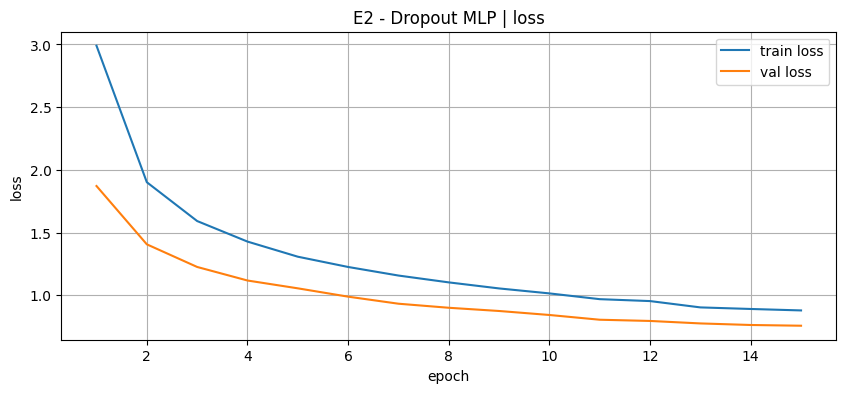

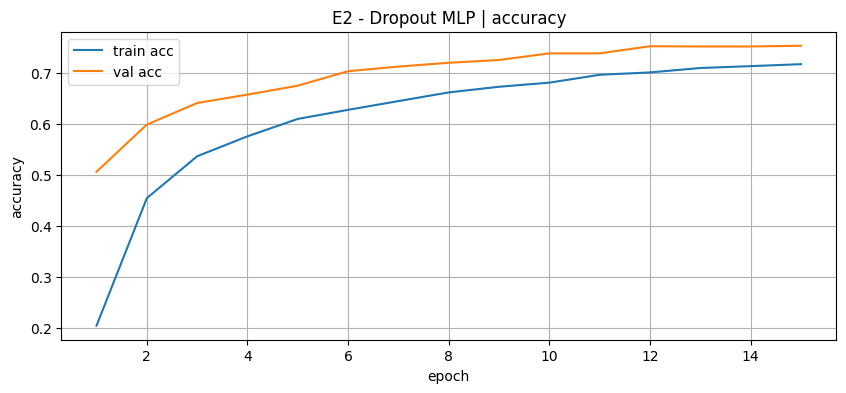

best accuracy: 0.754


In [7]:
set_seed()
model_E2 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.3, 
              use_batchnorm=False)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_E2.parameters(), lr=1e-3, weight_decay=0)
history_E2 = fit(
    model_E2, train_loader, val_loader,
    optimizer, criterion,
    epochs=15,
    early_stopping=None
)
plot_history(history_E2, title="E2 - Dropout MLP")
E2_data = {'experiment_id': 'E2',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'Dropout = 0.3; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': 15,
            'best_val_accuracy': max(history_E2['val_acc']),
            'best_val_loss': min(history_E2['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E2_data])], ignore_index=True)
print(f"best accuracy: {max(history_E2['val_acc'])}")


#### Эксперимент E3 (BatchNorm)

Epoch 01/15 | train loss 2.2507, acc 0.496 | val loss 1.5099, acc 0.630 | 2.9s
Epoch 02/15 | train loss 1.1211, acc 0.717 | val loss 1.0642, acc 0.696 | 2.9s
Epoch 03/15 | train loss 0.7727, acc 0.785 | val loss 0.8768, acc 0.729 | 3.0s
Epoch 04/15 | train loss 0.5934, acc 0.827 | val loss 0.7958, acc 0.754 | 2.9s
Epoch 05/15 | train loss 0.4723, acc 0.859 | val loss 0.7281, acc 0.766 | 2.9s
Epoch 06/15 | train loss 0.3859, acc 0.881 | val loss 0.7520, acc 0.760 | 2.9s
Epoch 07/15 | train loss 0.3288, acc 0.896 | val loss 0.7146, acc 0.763 | 5.2s
Epoch 08/15 | train loss 0.2742, acc 0.912 | val loss 0.7230, acc 0.768 | 2.8s
Epoch 09/15 | train loss 0.2277, acc 0.931 | val loss 0.7227, acc 0.777 | 2.8s
Epoch 10/15 | train loss 0.2030, acc 0.936 | val loss 0.7422, acc 0.766 | 2.9s
Epoch 11/15 | train loss 0.1779, acc 0.948 | val loss 0.7604, acc 0.767 | 2.7s
Epoch 12/15 | train loss 0.1646, acc 0.948 | val loss 0.7924, acc 0.763 | 2.7s
Epoch 13/15 | train loss 0.1461, acc 0.956 | val los

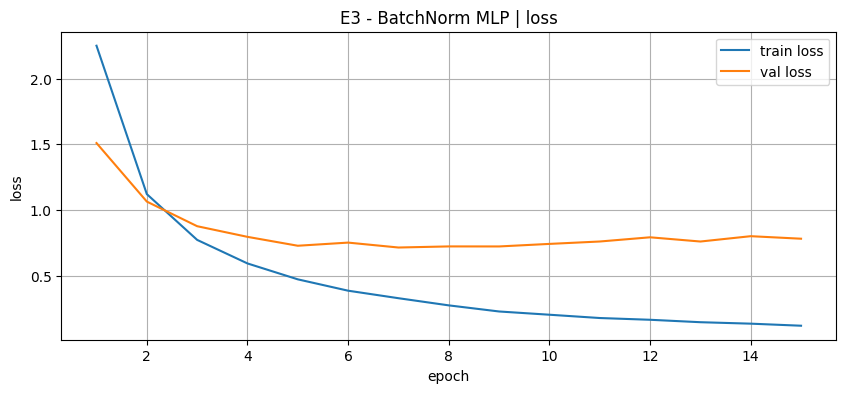

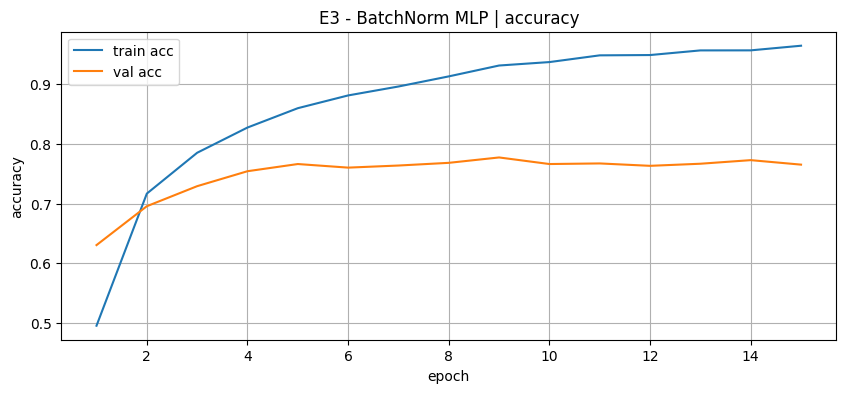

best accuracy: 0.777


In [8]:
set_seed()
model_E3 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_E3.parameters(), lr=1e-3, weight_decay=0)
history_E3 = fit(
    model_E3, train_loader, val_loader,
    optimizer, criterion,
    epochs=15,
    early_stopping=None
)
plot_history(history_E3, title="E3 - BatchNorm MLP")
E3_data = {'experiment_id': 'E3',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'BatchNorm; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': 15,
            'best_val_accuracy': max(history_E3['val_acc']),
            'best_val_loss': min(history_E3['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E3_data])], ignore_index=True)
print(f"best accuracy: {max(history_E3['val_acc'])}")


#### Эксперимент E4 (EarlyStopping)

Epoch 01/15 | train loss 2.2507, acc 0.496 | val loss 1.5099, acc 0.630 | 2.8s
Epoch 02/15 | train loss 1.1211, acc 0.717 | val loss 1.0642, acc 0.696 | 2.7s
Epoch 03/15 | train loss 0.7727, acc 0.785 | val loss 0.8768, acc 0.729 | 2.7s
Epoch 04/15 | train loss 0.5934, acc 0.827 | val loss 0.7958, acc 0.754 | 2.8s
Epoch 05/15 | train loss 0.4723, acc 0.859 | val loss 0.7281, acc 0.766 | 2.7s
Epoch 06/15 | train loss 0.3859, acc 0.881 | val loss 0.7520, acc 0.760 | 2.7s
Epoch 07/15 | train loss 0.3288, acc 0.896 | val loss 0.7146, acc 0.763 | 2.7s
Epoch 08/15 | train loss 0.2742, acc 0.912 | val loss 0.7230, acc 0.768 | 2.7s
Epoch 09/15 | train loss 0.2277, acc 0.931 | val loss 0.7227, acc 0.777 | 2.7s
Epoch 10/15 | train loss 0.2030, acc 0.936 | val loss 0.7422, acc 0.766 | 2.7s
Epoch 11/15 | train loss 0.1779, acc 0.948 | val loss 0.7604, acc 0.767 | 2.7s
Epoch 12/15 | train loss 0.1646, acc 0.948 | val loss 0.7924, acc 0.763 | 2.7s
Epoch 13/15 | train loss 0.1461, acc 0.956 | val los

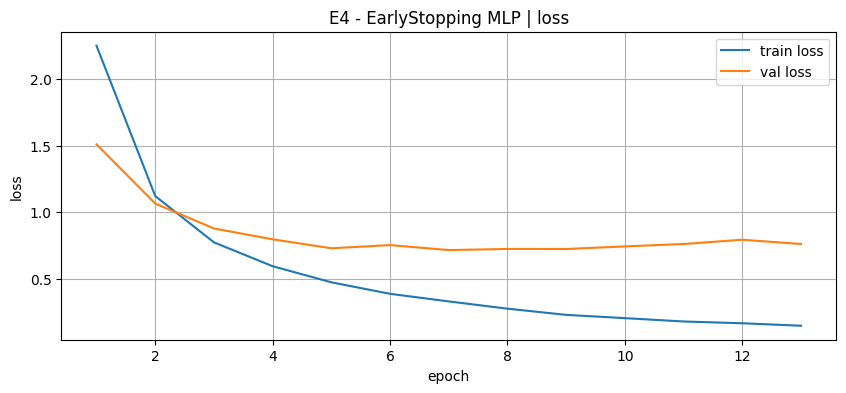

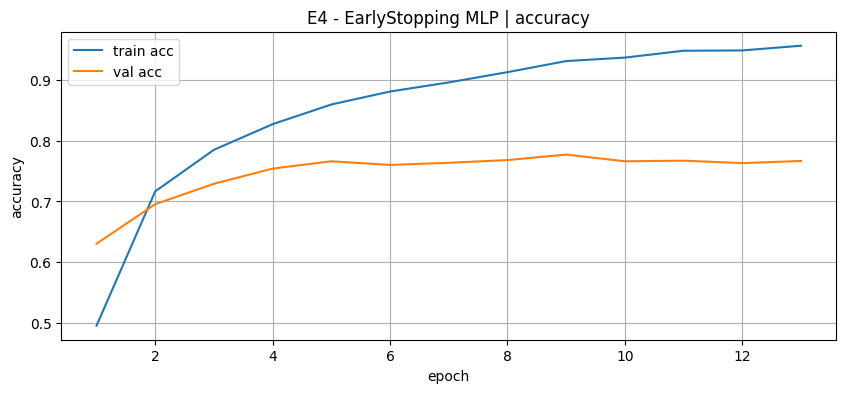

In [9]:
set_seed()
model_E4 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_E4.parameters(), lr=1e-3, weight_decay=0)
es = EarlyStopping(patience=4, min_delta=0.0005)
history_E4 = fit(
    model_E4, train_loader, val_loader,
    optimizer, criterion,
    epochs=15,
    early_stopping=es
)
plot_history(history_E4, title="E4 - EarlyStopping MLP",save=True)
E4_data = {'experiment_id': 'E4',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'EarlyStopping + E3; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 1e-3,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': len(history_E4['val_acc']),
            'best_val_accuracy': max(history_E4['val_acc']),
            'best_val_loss': min(history_E4['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([E4_data])], ignore_index=True)

# сохранённый state_dict() лучшей модели (E4)
torch.save(model_E4.state_dict(), 'artifacts/best_model.pt')


In [10]:
# Сохранение конфига лучшей модели
best_config = runs.iloc[3].to_dict()
best_config.pop('experiment_id')
best_config['net'] = 'Sequential'
best_config['net_layers'] = ['Flatten(start_dim=1, end_dim=-1)',
                             'Linear(in_features=784, out_features=256, bias=True)',
                             'BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)',
                            'ReLU()',
                            'Linear(in_features=256, out_features=128, bias=True)',
                            'BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)',
                            'ReLU()',
                            'Linear(in_features=128, out_features=47, bias=True)']
best_config['activation'] = 'ReLu'
best_config['model_summary'] = 'EarlyStopping + BatchNorm'
best_config['early_stopping_patience'] = 4
best_config['early_stopping_min_delta'] = 0.0005
best_config['criterion'] = 'CrossEntropyLoss'

criterion
#print(best_config)
with open('artifacts/best_config.json', 'w', encoding='utf-8') as f:
    json.dump(best_config, f, ensure_ascii=False, indent=4)
print("Saved:", "best_config.json")

Saved: best_config.json


### Часть B (S09): LR, оптимизаторы, weight decay

#### Эксперимент O1 (LR слишком большой)

Epoch 01/6 | train loss 3.8972, acc 0.093 | val loss 3.3294, acc 0.133 | 2.8s
Epoch 02/6 | train loss 2.9204, acc 0.174 | val loss 2.8473, acc 0.202 | 2.8s
Epoch 03/6 | train loss 2.6329, acc 0.228 | val loss 2.5394, acc 0.282 | 2.8s
Epoch 04/6 | train loss 2.3739, acc 0.287 | val loss 3.9890, acc 0.200 | 2.8s
Epoch 05/6 | train loss 2.1787, acc 0.331 | val loss 2.1701, acc 0.342 | 2.8s
Epoch 06/6 | train loss 2.0243, acc 0.376 | val loss 2.5083, acc 0.318 | 2.7s


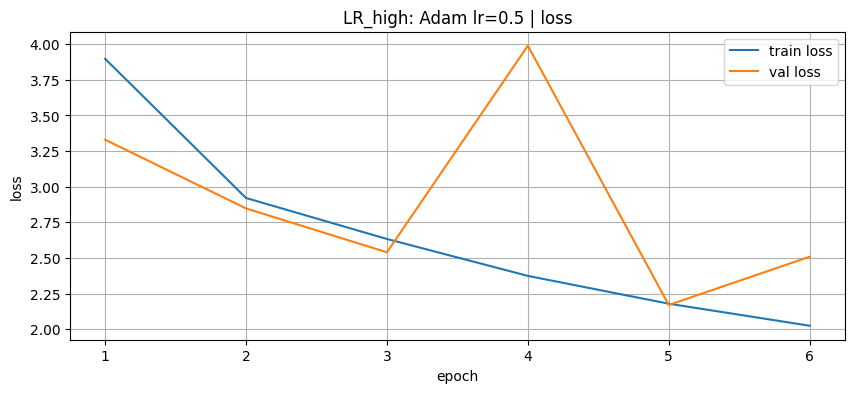

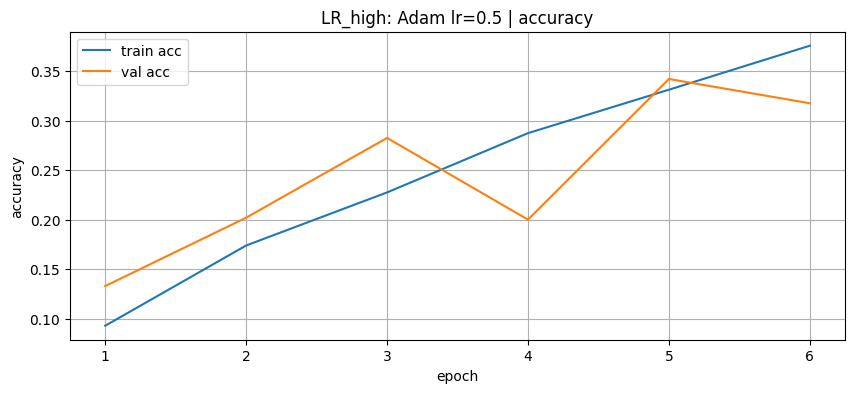

In [11]:
set_seed()
model_O1 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer_too_big = torch.optim.Adam(model_O1.parameters(), lr=0.5, weight_decay=0)
history_O1 = fit(
    model_O1, train_loader, val_loader,
    optimizer_too_big, criterion,
    epochs=6,
)
plot_history(history_O1, title="LR_high: Adam lr=0.5")
O1_data = {'experiment_id': 'O1',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'E4 with lr = 1e-1; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 0.5,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': len(history_O1['val_acc']),
            'best_val_accuracy': max(history_O1['val_acc']),
            'best_val_loss': min(history_O1['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O1_data])], ignore_index=True)


#### Эксперимент O2 (LR слишком маленький)

Epoch 01/6 | train loss 3.8628, acc 0.034 | val loss 3.7782, acc 0.049 | 2.7s
Epoch 02/6 | train loss 3.7106, acc 0.071 | val loss 3.6410, acc 0.097 | 2.7s
Epoch 03/6 | train loss 3.5779, acc 0.115 | val loss 3.5216, acc 0.144 | 2.8s
Epoch 04/6 | train loss 3.4607, acc 0.163 | val loss 3.4158, acc 0.182 | 2.8s
Epoch 05/6 | train loss 3.3568, acc 0.209 | val loss 3.3216, acc 0.225 | 2.7s
Epoch 06/6 | train loss 3.2658, acc 0.252 | val loss 3.2374, acc 0.260 | 2.7s


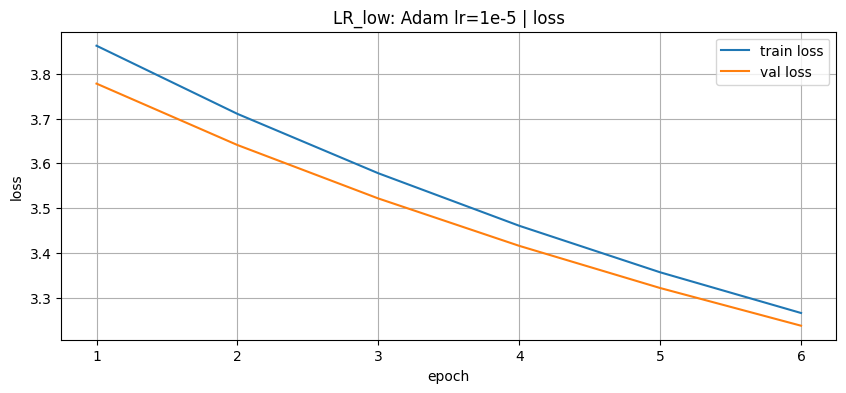

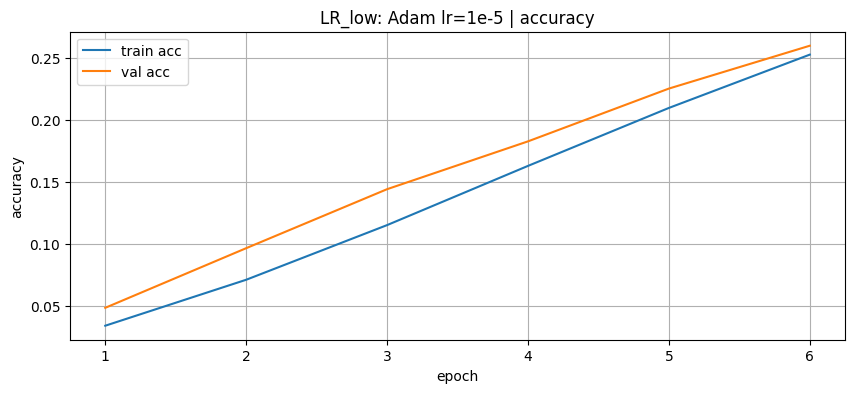

In [12]:
set_seed()
model_O2 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer_too_low = torch.optim.Adam(model_O2.parameters(), lr=1e-5, weight_decay=0)
history_O2 = fit(
    model_O2, train_loader, val_loader,
    optimizer_too_low, criterion,
    epochs=6,
)
plot_history(history_O2, title="LR_low: Adam lr=1e-5")

O2_data = {'experiment_id': 'O2',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'E4 with lr = 1e-5; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'Adam',
            'lr': 1e-5,
            'momentum': 0,
            'weight_decay': 0,
            'epochs_trained': len(history_O2['val_acc']),
            'best_val_accuracy': max(history_O2['val_acc']),
            'best_val_loss': min(history_O2['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O2_data])], ignore_index=True)


#### Эксперимент O3 (SGD+momentum + weight decay)

Epoch 01/15 | train loss 3.5453, acc 0.145 | val loss 3.1682, acc 0.289 | 2.7s
Epoch 02/15 | train loss 2.9485, acc 0.386 | val loss 2.7563, acc 0.423 | 2.7s
Epoch 03/15 | train loss 2.5912, acc 0.486 | val loss 2.4636, acc 0.502 | 2.7s
Epoch 04/15 | train loss 2.3150, acc 0.550 | val loss 2.2310, acc 0.540 | 2.7s
Epoch 05/15 | train loss 2.0861, acc 0.590 | val loss 2.0360, acc 0.574 | 2.7s
Epoch 06/15 | train loss 1.8957, acc 0.620 | val loss 1.8710, acc 0.604 | 2.7s
Epoch 07/15 | train loss 1.7344, acc 0.643 | val loss 1.7327, acc 0.621 | 2.7s
Epoch 08/15 | train loss 1.5945, acc 0.669 | val loss 1.6223, acc 0.637 | 2.7s
Epoch 09/15 | train loss 1.4787, acc 0.683 | val loss 1.5198, acc 0.654 | 2.7s
Epoch 10/15 | train loss 1.3745, acc 0.700 | val loss 1.4354, acc 0.659 | 2.7s
Epoch 11/15 | train loss 1.2885, acc 0.711 | val loss 1.3585, acc 0.671 | 2.7s
Epoch 12/15 | train loss 1.2089, acc 0.726 | val loss 1.2906, acc 0.683 | 2.7s
Epoch 13/15 | train loss 1.1360, acc 0.738 | val los

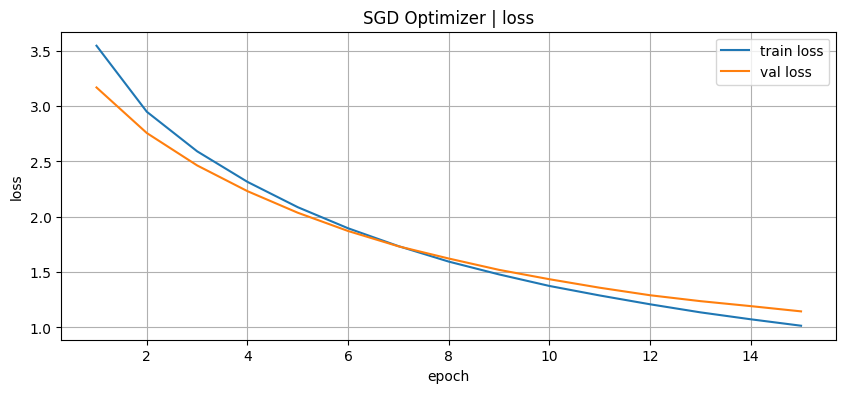

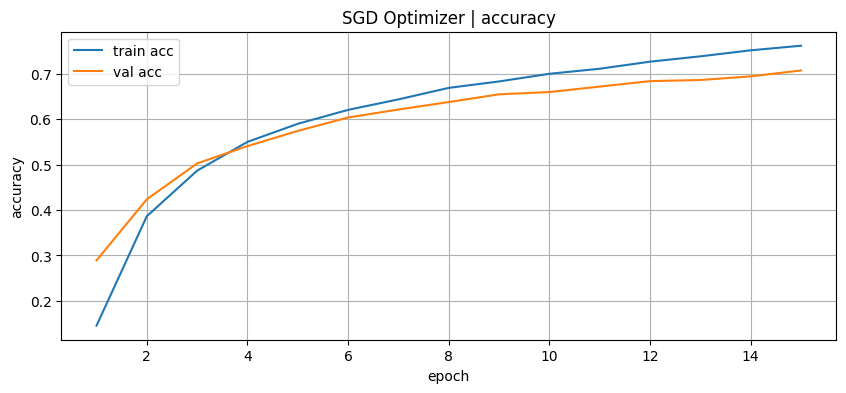

In [13]:
set_seed()
model_O3 = MLP(input_dim = INPUT_DIM, 
              num_classes=NUM_CLASSES, 
              hidden_sizes=(256, 128), 
              dropout=0.0, 
              use_batchnorm=True)
criterion = nn.CrossEntropyLoss()
optimizer_SGD = torch.optim.SGD(model_O3.parameters(), lr=1e-3, momentum=0.9, weight_decay=1e-4)
history_O3 = fit(
    model_O3, train_loader, val_loader,
    optimizer_SGD, criterion,
    epochs=15,
)
plot_history(history_O3, title="SGD Optimizer")
O3_data = {'experiment_id': 'O3',
           'dataset': 'EMNIST',
           'seed': 42,
           'model_summary': 'E4 with SGD Optimizer; hidden sizes = (256, 128); activation = ReLU',
            'optimizer': 'SGD',
            'lr': 1e-3,
            'momentum': 0.9,
            'weight_decay': 1e-4,
            'epochs_trained': len(history_O3['val_acc']),
            'best_val_accuracy': max(history_O3['val_acc']),
            'best_val_loss': min(history_O3['val_loss'])}
runs = pd.concat([runs, pd.DataFrame([O3_data])], ignore_index=True)


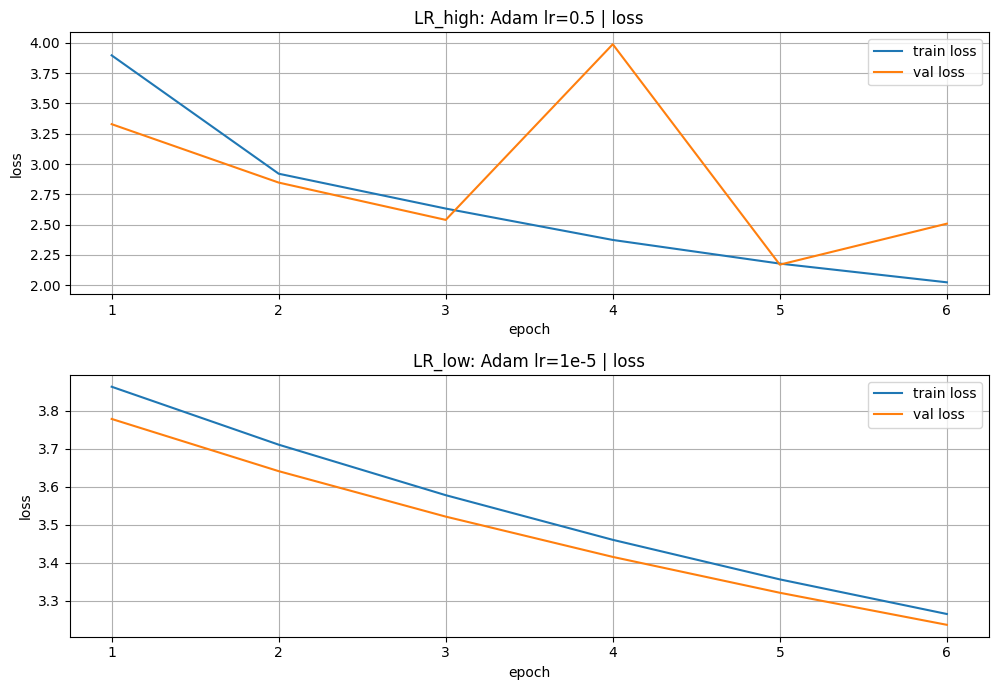

In [14]:
# построение графиков экстремальных кривых


# построение графиков изменения loss и acc


plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
epochs = list(range(1, len(history_O1["train_loss"]) + 1))
plt.plot(epochs, history_O1["train_loss"], label="train loss")
plt.plot(epochs, history_O1["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("LR_high: Adam lr=0.5 | loss")
plt.grid(True)
plt.legend()

plt.subplot(2, 1, 2)
epochs = list(range(1, len(history_O2["train_loss"]) + 1))
plt.plot(epochs, history_O2["train_loss"], label="train loss")
plt.plot(epochs, history_O2["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("LR_low: Adam lr=1e-5 | loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png")
plt.show()


In [15]:
# Проверяем лучшую модель на test 
set_seed(42)
test_loss, test_acc = evaluate(model_E4, test_loader, criterion)
print(f"E4 test: loss={test_loss:.4f}, acc={test_acc:.4f}")

display(runs)
runs.to_csv("artifacts/runs.csv")

E4 test: loss=0.7945, acc=0.7617


,experiment_id,dataset,seed,model_summary,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
0,E1,EMNIST,42,"base; hidden sizes = (256, 128); activation = ...",Adam,0.00100,0,0,15,0.7590,0.759732
1,E2,EMNIST,42,"Dropout = 0.3; hidden sizes = (256, 128); acti...",Adam,0.00100,0,0,15,0.7540,0.756750
2,E3,EMNIST,42,"BatchNorm; hidden sizes = (256, 128); activati...",Adam,0.00100,0,0,15,0.7770,0.714615
3,E4,EMNIST,42,"EarlyStopping + E3; hidden sizes = (256, 128);...",Adam,0.00100,0,0,13,0.7770,0.714615
4,O1,EMNIST,42,"E4 with lr = 1e-1; hidden sizes = (256, 128); ...",Adam,0.50000,0,0,6,0.3420,2.170059
5,O2,EMNIST,42,"E4 with lr = 1e-5; hidden sizes = (256, 128); ...",Adam,0.00001,0,0,6,0.2595,3.237429
6,O3,EMNIST,42,"E4 with SGD Optimizer; hidden sizes = (256, 12...",SGD,0.00100,0.9,0.0001,15,0.7070,1.144868
